# SHAP Explainability Analysis — Australia Habitat (Pretrained VGGish + Random Forest)

**Branch:** `research/shap-explainability`  
**Based on:** `rf_pretrained_cnn_aus_habitat_REPRODUCTION.ipynb`  
**Purpose:** Add SHAP (SHapley Additive exPlanations) as an additive analysis layer on top of the unchanged baseline.

---

## What this notebook does

1. **Runs the identical baseline** — the 32-fold leave-one-site-out CV, 50-seed RF selection, and all accuracy/confusion-matrix calculations are byte-for-byte identical to the REPRODUCTION notebook.
2. **Adds SHAP collection inside the fold loop** — when a new best model is found during the 50-seed inner loop, `best_model_ref` and the corresponding test data are saved. After the 50-seed loop completes, `shap.TreeExplainer` is applied to that fold's held-out test set only.
3. **Aggregates SHAP across all 32 folds** — mirrors the accuracy reporting (mean ± std) for scientific consistency.
4. **Produces visualisations** — beeswarm summary, global importance bar chart, class-specific analysis, correct-vs-incorrect analysis, waterfall plots.

---

## What SHAP is doing here

SHAP (Lundberg & Lee, 2017) assigns each feature a contribution value for each prediction, grounded in cooperative game theory (Shapley values). For a Random Forest, `shap.TreeExplainer` computes **exact** Shapley values by traversing the decision paths of all trees — it is not an approximation.

Here, the features are the **128 output dimensions of VGGish's final fully-connected layer** (`fc2`). These are learned, nonlinear acoustic projections — not physical frequency bands.

---

## ⚠️  What the 128 VGGish dimensions ARE and ARE NOT

**ARE:** Learned 128-dimensional embedding coordinates. Each dimension is a nonlinear transformation of the input log-mel spectrogram, trained on AudioSet (general audio classification). High SHAP magnitude on a dimension means the Random Forest relies heavily on that learned acoustic feature to distinguish 'High fish' from 'Low fish' reef habitat.

**ARE NOT:** Physical frequency bands, time windows, or identifiable acoustic events (e.g., snapping shrimp). There is no direct mapping from VGGish dimension _k_ to a frequency in Hz.

---

## Scientifically valid claims from this analysis

✅ "VGGish dimensions {k, m, n} have the highest cross-validated |SHAP|, indicating the RF relies most on these learned acoustic features for habitat discrimination."

✅ "Correctly classified recordings have systematically different SHAP profiles from misclassified recordings."

✅ "The RF's reliance is {concentrated / distributed} across the 128 embedding dimensions."

✅ "Compared across the 32 CV folds, SHAP importance is stable (low ± std), suggesting robust feature usage."

## Scientifically invalid claims to avoid

❌ "VGGish dimension k corresponds to frequency X Hz."

❌ "The model uses snapping shrimp frequencies to classify habitat."

❌ "High SHAP on dimension k means high-frequency content drives the decision."

---
## Cell 1 — Imports (baseline + SHAP)

In [1]:
# ── BASELINE IMPORTS (unchanged from REPRODUCTION notebook) ──────────────────
from __future__ import division

import sklearn
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
from sklearn.model_selection import train_test_split
import statistics

from sklearn.metrics import confusion_matrix

import collections
from sklearn.metrics import ConfusionMatrixDisplay

import seaborn as sn
import matplotlib.pyplot as plt

# ── SHAP EXTENSION IMPORTS ────────────────────────────────────────────────────
import shap
import os
import json
import warnings
warnings.filterwarnings('ignore')   # suppress numba/shap deprecation noise

print(f'shap version:    {shap.__version__}')
print(f'sklearn version: {sklearn.__version__}')
print(f'numpy version:   {np.__version__}')
print(f'pandas version:  {pd.__version__}')

# Confirm SHAP API shape for this installation
def _shap_api_check():
    import numpy as _np
    from sklearn.ensemble import RandomForestClassifier as _RF
    _X = _np.random.rand(50, 4).astype(_np.float32)
    _y = ['A']*25 + ['B']*25
    _m = _RF(n_estimators=3, random_state=0).fit(_X, _y)
    _exp = shap.TreeExplainer(_m, feature_perturbation='tree_path_dependent')
    _sv = _exp.shap_values(_X[:5])
    if isinstance(_sv, list):
        return 'list', None   # old API: list[n_classes][n_samples, n_features]
    else:
        return 'array3d', _sv.shape  # new API: [n_samples, n_features, n_classes]

SHAP_API, _shape = _shap_api_check()
print(f'SHAP API style:  {SHAP_API}  {"shape=" + str(_shape) if _shape else ""}')

C:\Users\pande\.conda\envs\reef-baseline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap version:    0.49.1
sklearn version: 1.0.2
numpy version:   1.26.4
pandas version:  1.3.5
SHAP API style:  array3d  shape=(5, 4, 2)


---
## Cell 2 — Paths and configuration

In [2]:
# ── BASELINE PATH (unchanged from REPRODUCTION notebook) ─────────────────────
path = r'C:\Code\Reef-acoustics-and-AI-main\data\pretrained_CNN_aus.csv'

num_classes = 2
labels = ['High fish', 'Low fish']

# ── SHAP EXTENSION: output directory ─────────────────────────────────────────
# This directory is listed in .gitignore (outputs/) so generated arrays and
# plots are not accidentally committed.
SHAP_OUTPUT_DIR = r'C:\Code\Reef-acoustics-and-AI-main\outputs\shap_aus_habitat'
os.makedirs(SHAP_OUTPUT_DIR, exist_ok=True)
print(f'SHAP outputs will be saved to: {SHAP_OUTPUT_DIR}')

# Feature name labels for all SHAP plots
# NOTE: These are VGGish embedding dimension indices — NOT physical frequency bands.
FEATURE_NAMES = [f'VGGish_dim_{d}' for d in range(128)]

SHAP outputs will be saved to: C:\Code\Reef-acoustics-and-AI-main\outputs\shap_aus_habitat


---
## Cell 3 — Load and reshape CSV

In [3]:
# ── BASELINE (unchanged from REPRODUCTION notebook) ───────────────────────────
data = pd.read_csv(path)
df = data.reset_index() 
df = df.iloc[: , 2:]  # remove additional index
temp_df = data.reset_index()  # put index in order
temp_df = temp_df.iloc[: , 2:]  # remove unnecessary index
temp_df = temp_df.T  # transpose to match indices format
temp_df = temp_df.reset_index()  # re-add the index
df = temp_df.rename(columns={"index": "minute"})

print(f'DataFrame shape after load+transpose: {df.shape}')
print(f'Expected: (8975, 129)  [minute + 128 VGGish dims]')
df

DataFrame shape after load+transpose: (8975, 129)
Expected: (8975, 129)  [minute + 128 VGGish dims]


,minute,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,SiteJdeployment2.1677983769.181103032034.wav,0.000929,0.093042,0.285380,0.210208,0.000000,0.0,0.0,0.006659,0.000000,...,0.0,0.023046,0.000220,0.000000,0.000000,0.225300,0.304314,0.000000,0.000000,0.0
1,SiteAdeployment1.805322778.181023172733.wav,0.030780,0.100007,0.408427,0.050889,0.000000,0.0,0.0,0.002414,0.000000,...,0.0,0.060092,0.010739,0.000000,0.028925,0.244283,0.167082,0.000000,0.000000,0.0
2,SiteIdeployment2.805322778.181102073302.wav,0.023870,0.043412,0.331813,0.121506,0.000000,0.0,0.0,0.000000,0.000255,...,0.0,0.043277,0.000077,0.000000,0.016917,0.357364,0.186497,0.000000,0.000000,0.0
3,SiteDdeployment4.805322778.181123173922.wav,0.039953,0.076123,0.304760,0.088957,0.001289,0.0,0.0,0.014608,0.000000,...,0.0,0.078101,0.053534,0.001675,0.013040,0.177259,0.129732,0.000000,0.000000,0.0
4,SiteEdeployment6.1677983769.181209085140.wav,0.005541,0.105616,0.485045,0.074837,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.056985,0.008627,0.000000,0.020391,0.282245,0.129462,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8970,SiteEdeployment4.1677983769.181123193512.wav,0.005815,0.111684,0.373035,0.186946,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.085167,0.000000,0.000137,0.029835,0.296419,0.188369,0.000000,0.001338,0.0
8971,SiteBdeployment2.1678278701.181031081236.wav,0.001825,0.060861,0.343262,0.226211,0.000142,0.0,0.0,0.000000,0.000000,...,0.0,0.030873,0.000000,0.000467,0.000219,0.443077,0.304441,0.000000,0.000000,0.0
8972,SiteFdeployment1.805322778.181024160925.wav,0.036383,0.040715,0.350639,0.109169,0.001251,0.0,0.0,0.021016,0.000000,...,0.0,0.080465,0.019677,0.000822,0.004993,0.170270,0.152097,0.000000,0.000000,0.0
8973,SiteHdeployment2.805322778.181103064253.wav,0.024534,0.068714,0.446816,0.091898,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.165965,0.007297,0.000000,0.196851,0.172095,0.139393,0.000565,0.000000,0.0


---
## Cell 4 — Assign habitat labels, drop excluded sites

In [4]:
# ── BASELINE (unchanged from REPRODUCTION notebook) ───────────────────────────
def get_class(filename):
    site = filename[0:5]
    return site
    
df_withclasses = df

new_list = []
for i in range(len(df_withclasses)):
    new_list.append(get_class(df_withclasses['minute'][i]))

df_withclasses.insert(1, 'Class', new_list)

pretrained_df = df_withclasses 

# Remove the 4 sites not being used for fish habitat comparison
pretrained_df.drop(pretrained_df.index[pretrained_df['Class'] == 'SiteC'], inplace=True)
pretrained_df.drop(pretrained_df.index[pretrained_df['Class'] == 'SiteD'], inplace=True)
pretrained_df.drop(pretrained_df.index[pretrained_df['Class'] == 'SiteE'], inplace=True)
pretrained_df.drop(pretrained_df.index[pretrained_df['Class'] == 'SiteI'], inplace=True)

# Rename the remaining sites to High or Low fish
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteA'],'Low fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteB'],'Low fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteG'],'Low fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteJ'],'Low fish')

pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteF'],'High fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteH'],'High fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteK'],'High fish')
pretrained_df['Class'] = pretrained_df['Class'].replace(['SiteL'],'High fish')

pretrained_df.reset_index(drop=True, inplace=True)
print(f'After filtering: {pretrained_df.shape}')
print(pretrained_df['Class'].value_counts())
pretrained_df.head()

After filtering: (6106, 130)
High fish    3220
Low fish     2886
Name: Class, dtype: int64


,minute,Class,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,SiteJdeployment2.1677983769.181103032034.wav,Low fish,0.000929,0.093042,0.285380,0.210208,0.0,0.0,0.0,0.006659,...,0.0,0.023046,0.000220,0.000000,0.000000,0.225300,0.304314,0.0,0.0,0.0
1,SiteAdeployment1.805322778.181023172733.wav,Low fish,0.030780,0.100007,0.408427,0.050889,0.0,0.0,0.0,0.002414,...,0.0,0.060092,0.010739,0.000000,0.028925,0.244283,0.167082,0.0,0.0,0.0
2,SiteBdeployment5.1677983769.181201071827.wav,Low fish,0.002083,0.104573,0.366874,0.168646,0.0,0.0,0.0,0.001900,...,0.0,0.039408,0.008483,0.002023,0.026743,0.295693,0.211083,0.0,0.0,0.0
3,SiteAdeployment6.805322778.181208200239.wav,Low fish,0.028723,0.063788,0.302572,0.160899,0.0,0.0,0.0,0.003868,...,0.0,0.077238,0.007906,0.000191,0.039737,0.211901,0.197882,0.0,0.0,0.0
4,SiteJdeployment3.1677983769.181110075705.wav,Low fish,0.001223,0.154777,0.341569,0.162932,0.0,0.0,0.0,0.000000,...,0.0,0.026811,0.000020,0.000000,0.003966,0.317349,0.288543,0.0,0.0,0.0


---
## Cell 5 — Add Site column

In [5]:
# ── BASELINE (unchanged from REPRODUCTION notebook) ───────────────────────────
def similar(x, y):
    si = 0
    for a, b in zip(x, y):
        if a == b:
            si += 1
    return (si / len(x)) * 100

def get_class(filename):
    site = filename[0:5]
    return site
    
df_withclasses = df

new_list = []
for i in range(len(df_withclasses)):
    new_list.append(get_class(pretrained_df['minute'][i]))

pretrained_df.insert(1, 'Site', new_list)

# Confirm column layout: [minute, Site, Class, 0, 1, ..., 127]
print('Column layout:', list(pretrained_df.columns[:5]), '...', list(pretrained_df.columns[-3:]))
print(f'Total columns: {len(pretrained_df.columns)}  (expected 130: minute + Site + Class + 128 dims)')

Column layout: ['minute', 'Site', 'Class', 0, 1] ... [125, 126, 127]
Total columns: 131  (expected 130: minute + Site + Class + 128 dims)


---
## Cell 6 — Initialise SHAP collection containers

These containers accumulate per-fold data during the 32-fold loop below.
They are **additional** to the baseline's `all_saved_test_accs` and `ConfusionMatrix` accumulators.
The baseline accumulators are not modified.

In [6]:
# ── SHAP EXTENSION: per-fold containers ──────────────────────────────────────
# Each list has one entry per CV fold (32 total after the full loop).

shap_fold_sv           = []   # [n_test, 128] SHAP values for 'High fish' class per fold
shap_fold_test_feats   = []   # [n_test, 128] feature values per fold
shap_fold_filenames    = []   # [n_test]      recording filenames per fold
shap_fold_labels       = []   # [n_test]      true labels per fold
shap_fold_predictions  = []   # [n_test]      model predictions per fold
shap_fold_proba        = []   # [n_test, 2]   class probabilities per fold
shap_fold_expected_val = []   # scalar        SHAP base value (E[f(X)]) for 'High fish' per fold
shap_fold_ids          = []   # tuple         fold metadata for traceability
shap_fold_classes_     = []   # list          model.classes_ per fold

print('SHAP containers initialised.')
print(f'SHAP API in use: {SHAP_API}')

SHAP containers initialised.
SHAP API in use: array3d


---
## Cell 7 — 32-fold RF training loop WITH SHAP collection

**Baseline logic is completely unchanged.** SHAP lines are marked with `# [SHAP]` comments.

SHAP uses `feature_perturbation='tree_path_dependent'` (TreeExplainer default).
This requires **no background dataset** and avoids data leakage entirely.
SHAP is computed on the **held-out test set only** — never on train or val data.

In [7]:
def _extract_sv_for_class(sv_raw, class_idx, api=SHAP_API):
    """Extract SHAP values for one class, handling both SHAP API versions.

    SHAP < 0.41 (old API): shap_values() returns list of [n_samples, n_features] per class.
    SHAP >= 0.41 (new API): shap_values() returns ndarray [n_samples, n_features, n_classes].
    Returns: ndarray [n_samples, n_features]
    """
    if api == 'list' or isinstance(sv_raw, list):
        return np.array(sv_raw[class_idx])         # [n_samples, n_features]
    else:
        return sv_raw[:, :, class_idx]             # [n_samples, n_features, n_classes] → slice

def _extract_expected_val(exp_val_raw, class_idx, api=SHAP_API):
    """Extract expected value for one class from explainer.expected_value."""
    if isinstance(exp_val_raw, (list, np.ndarray)):
        return float(exp_val_raw[class_idx])
    return float(exp_val_raw)   # scalar (rare for binary)


# ── BASELINE INITIALISATIONS (unchanged) ─────────────────────────────────────
all_saved_test_accs        = []
whole_site_saved_test_accs = []
ConfusionMatrix = np.zeros((num_classes, num_classes), dtype=float)

# ─────────────────────────────────────────────────────────────────────────────
# PART 1: outer loop = low-fish site held out; inner loop = high-fish site held out
# ─────────────────────────────────────────────────────────────────────────────
for i in range(4):   # 4 sites in the lowfish class
  low_fish = ['SiteA', 'SiteB', 'SiteG', 'SiteJ']
  remove_low = low_fish[i]
  train_low_fish = low_fish 
  train_low_fish.remove(remove_low)
  for k in range(4):   # 4 sites in the highfish class
    thisCV_saved_test_accs     = []
    thisCV_saved_test_day_accs = []

    high_fish = ['SiteH', 'SiteF', 'SiteK', 'SiteL']
    remove_high = high_fish[k]
    train_high_fish = high_fish 
    train_high_fish.remove(remove_high)

    # ── Make train/val/test dataframes ───────────────────────────────────────
    train_df = pretrained_df.loc[pretrained_df['Site'].isin(train_low_fish)]
    train_df = train_df.append(pretrained_df.loc[pretrained_df['Site'].isin(train_high_fish)])

    lowfish_df  = pretrained_df.loc[pretrained_df['Site'] == remove_low]
    highfish_df = pretrained_df.loc[pretrained_df['Site'] == remove_high]
    val_df  = lowfish_df.iloc[::2, :]    # even rows → val
    val_df  = val_df.append(highfish_df.iloc[::2, :])
    test_df = lowfish_df.iloc[1::2, :]   # odd rows → test
    test_df = test_df.append(highfish_df.iloc[1::2, :])

    # ── Shuffle (fixed seed as in baseline) ──────────────────────────────────
    np.random.seed(123)
    train_df = train_df.sample(frac=1)
    val_df   = val_df.sample(frac=1)
    test_df  = test_df.sample(frac=1)
    np.random.seed()

    # ── Feature/label arrays ─────────────────────────────────────────────────
    train_feats  = train_df.iloc[:, 3:].to_numpy()
    train_labels = train_df.iloc[:, 2].to_numpy()
    val_feats    = val_df.iloc[:, 3:].to_numpy()
    val_labels   = val_df.iloc[:, 2].to_numpy()
    test_feats   = test_df.iloc[:, 3:].to_numpy()
    test_labels  = test_df.iloc[:, 2].to_numpy()

    # [SHAP] Capture filenames alongside features for later traceability
    test_filenames = test_df['minute'].to_numpy().copy()

    # ── 50-seed inner loop ───────────────────────────────────────────────────
    val_accuracy_score      = 0
    best_model_ref          = None   # [SHAP] accumulates current best model
    best_test_feats_ref     = None
    best_test_labels_ref    = None
    best_test_pred_ref      = None
    best_test_filenames_ref = None

    for seed in range(50):
      # ── BASELINE: train and validate ────────────────────────────────────────
      model = RandomForestClassifier(n_jobs=-1, random_state=seed)
      model.fit(train_feats, train_labels)
      new_val_acc = model.score(val_feats, val_labels)

      if new_val_acc > val_accuracy_score:
        val_accuracy_score = new_val_acc

        # ── BASELINE: test inference ──────────────────────────────────────────
        test_acc         = model.score(test_feats, test_labels)
        test_predictions = model.predict(test_feats)
        best_ConfusionMatrix = confusion_matrix(test_labels, test_predictions, labels=labels)

        if similar(test_labels, test_predictions) >= 50:
          whole_site_acc = 1
        else:
          whole_site_acc = 0

        # [SHAP] Capture best model reference and its test data
        best_model_ref          = model
        best_test_feats_ref     = test_feats.copy()
        best_test_labels_ref    = test_labels.copy()
        best_test_pred_ref      = test_predictions.copy()
        best_test_filenames_ref = test_filenames.copy()

    # ── BASELINE: accumulate results ─────────────────────────────────────────
    ConfusionMatrix = np.add(ConfusionMatrix, best_ConfusionMatrix)
    thisCV_saved_test_accs.append(test_acc)
    all_saved_test_accs.append(test_acc)
    thisCV_saved_test_day_accs.append(whole_site_acc)
    whole_site_saved_test_accs.append(whole_site_acc)

    print(f'[P1 fold {len(all_saved_test_accs):02d}/16 | {remove_low} vs {remove_high}]'
          f'  1-min acc: {test_acc:.4f}  site acc: {whole_site_acc}')

    # ── [SHAP] Compute SHAP values on this fold's held-out test set only ─────
    # tree_path_dependent: no background dataset required; exact Shapley values.
    classes_order = list(best_model_ref.classes_)    # alphabetical: ['High fish', 'Low fish']
    hf_idx = classes_order.index('High fish')         # should be 0

    fold_explainer = shap.TreeExplainer(
        best_model_ref,
        feature_perturbation='tree_path_dependent'
    )
    fold_sv_raw = fold_explainer.shap_values(best_test_feats_ref)
    sv_hf = _extract_sv_for_class(fold_sv_raw, hf_idx)   # [n_test, 128]
    base_val_hf = _extract_expected_val(fold_explainer.expected_value, hf_idx)

    shap_fold_sv.append(sv_hf.copy())                              # [n_test, 128]
    shap_fold_test_feats.append(best_test_feats_ref.copy())        # [n_test, 128]
    shap_fold_filenames.append(best_test_filenames_ref.copy())     # [n_test]
    shap_fold_labels.append(best_test_labels_ref.copy())           # [n_test]
    shap_fold_predictions.append(best_test_pred_ref.copy())        # [n_test]
    shap_fold_proba.append(                                        # [n_test, 2]
        best_model_ref.predict_proba(best_test_feats_ref).copy())
    shap_fold_expected_val.append(base_val_hf)                     # scalar
    shap_fold_ids.append(('Part1', i, k, remove_low, remove_high))
    shap_fold_classes_.append(classes_order)

    thisCV_saved_test_accs     = []
    thisCV_saved_test_day_accs = []


# ─────────────────────────────────────────────────────────────────────────────
pt1_saved_test_accs            = list(all_saved_test_accs)
pt1_whole_site_saved_test_accs = list(whole_site_saved_test_accs)

def Average(lst): return sum(lst) / len(lst)
print(f'\nPart 1 ({len(pt1_saved_test_accs)} folds):'
      f'  1-min {Average(pt1_saved_test_accs):.4f} ± {np.std(pt1_saved_test_accs):.4f}'
      f'  site {Average(pt1_whole_site_saved_test_accs):.4f}')


# ─────────────────────────────────────────────────────────────────────────────
# PART 2: outer loop = high-fish site held out; inner loop = low-fish site held out
# ─────────────────────────────────────────────────────────────────────────────
all_saved_test_accs        = []
whole_site_saved_test_accs = []

for i in range(4):
  high_fish   = ['SiteH', 'SiteF', 'SiteK', 'SiteL']
  remove_high = high_fish[i]
  train_high_fish = high_fish 
  train_high_fish.remove(remove_high)
  for k in range(4):
    thisCV_saved_test_accs     = []
    thisCV_saved_test_day_accs = []

    low_fish   = ['SiteA', 'SiteB', 'SiteG', 'SiteJ']
    remove_low = low_fish[k]
    train_low_fish = low_fish 
    train_low_fish.remove(remove_low)

    # ── Make train/val/test dataframes ───────────────────────────────────────
    train_df = pretrained_df.loc[pretrained_df['Site'].isin(train_low_fish)]
    train_df = train_df.append(pretrained_df.loc[pretrained_df['Site'].isin(train_high_fish)])

    lowfish_df  = pretrained_df.loc[pretrained_df['Site'] == remove_low]
    highfish_df = pretrained_df.loc[pretrained_df['Site'] == remove_high]
    val_df  = lowfish_df.iloc[1::2, :]   # odd rows → val  (swapped from Part 1)
    val_df  = val_df.append(highfish_df.iloc[1::2, :])
    test_df = lowfish_df.iloc[::2, :]    # even rows → test
    test_df = test_df.append(highfish_df.iloc[::2, :])

    np.random.seed(123)
    train_df = train_df.sample(frac=1)
    val_df   = val_df.sample(frac=1)
    test_df  = test_df.sample(frac=1)
    np.random.seed()

    train_feats  = train_df.iloc[:, 3:].to_numpy()
    train_labels = train_df.iloc[:, 2].to_numpy()
    val_feats    = val_df.iloc[:, 3:].to_numpy()
    val_labels   = val_df.iloc[:, 2].to_numpy()
    test_feats   = test_df.iloc[:, 3:].to_numpy()
    test_labels  = test_df.iloc[:, 2].to_numpy()

    test_filenames = test_df['minute'].to_numpy().copy()  # [SHAP]

    val_accuracy_score      = 0
    best_model_ref          = None
    best_test_feats_ref     = None
    best_test_labels_ref    = None
    best_test_pred_ref      = None
    best_test_filenames_ref = None

    for seed in range(50):
      model = RandomForestClassifier(n_jobs=-1, random_state=seed)
      model.fit(train_feats, train_labels)
      new_val_acc = model.score(val_feats, val_labels)

      if new_val_acc > val_accuracy_score:
        val_accuracy_score = new_val_acc
        test_acc         = model.score(test_feats, test_labels)
        test_predictions = model.predict(test_feats)
        best_ConfusionMatrix = confusion_matrix(test_labels, test_predictions, labels=labels)

        if similar(test_labels, test_predictions) >= 50:
          whole_site_acc = 1
        else:
          whole_site_acc = 0

        # [SHAP] Capture best model reference
        best_model_ref          = model
        best_test_feats_ref     = test_feats.copy()
        best_test_labels_ref    = test_labels.copy()
        best_test_pred_ref      = test_predictions.copy()
        best_test_filenames_ref = test_filenames.copy()

    # ── BASELINE: accumulate ─────────────────────────────────────────────────
    ConfusionMatrix = np.add(ConfusionMatrix, best_ConfusionMatrix)
    thisCV_saved_test_accs.append(test_acc)
    all_saved_test_accs.append(test_acc)
    thisCV_saved_test_day_accs.append(whole_site_acc)
    whole_site_saved_test_accs.append(whole_site_acc)

    print(f'[P2 fold {len(all_saved_test_accs):02d}/16 | {remove_low} vs {remove_high}]'
          f'  1-min acc: {test_acc:.4f}  site acc: {whole_site_acc}')

    # ── [SHAP] Compute SHAP values ───────────────────────────────────────────
    classes_order = list(best_model_ref.classes_)
    hf_idx = classes_order.index('High fish')

    fold_explainer = shap.TreeExplainer(
        best_model_ref,
        feature_perturbation='tree_path_dependent'
    )
    fold_sv_raw = fold_explainer.shap_values(best_test_feats_ref)
    sv_hf = _extract_sv_for_class(fold_sv_raw, hf_idx)   # [n_test, 128]
    base_val_hf = _extract_expected_val(fold_explainer.expected_value, hf_idx)

    shap_fold_sv.append(sv_hf.copy())
    shap_fold_test_feats.append(best_test_feats_ref.copy())
    shap_fold_filenames.append(best_test_filenames_ref.copy())
    shap_fold_labels.append(best_test_labels_ref.copy())
    shap_fold_predictions.append(best_test_pred_ref.copy())
    shap_fold_proba.append(best_model_ref.predict_proba(best_test_feats_ref).copy())
    shap_fold_expected_val.append(base_val_hf)
    shap_fold_ids.append(('Part2', i, k, remove_low, remove_high))
    shap_fold_classes_.append(classes_order)

    thisCV_saved_test_accs     = []
    thisCV_saved_test_day_accs = []


# ─────────────────────────────────────────────────────────────────────────────
both_saved_test_accs            = pt1_saved_test_accs + all_saved_test_accs
both_whole_site_saved_test_accs = pt1_whole_site_saved_test_accs + whole_site_saved_test_accs

print('\n' + '='*65)
print('BASELINE RESULTS (all 32 folds complete)')
print('='*65)
mean_acc  = Average(both_saved_test_accs)
std_acc   = np.std(both_saved_test_accs)
mean_site = Average(both_whole_site_saved_test_accs)
std_site  = np.std(both_whole_site_saved_test_accs)
print(f'  Per-minute accuracy: {mean_acc:.4f} ± {std_acc:.4f}')
print(f'  Site-level accuracy: {mean_site:.4f} ± {std_site:.4f}')
print(f'  Reproduction target: 0.7194 ± 0.0855  /  1.0000 ± 0.0000')
print(f'  Confusion matrix:')
print(repr(ConfusionMatrix))
print(f'  Target CM: [[9138, 3742], [3100, 8444]]')
print()
print(f'SHAP folds collected: {len(shap_fold_sv)}  (expected 32)')
# Confirm all SHAP arrays have correct shape [n_test, 128]
shapes = set(sv.shape[1] for sv in shap_fold_sv)
print(f'SHAP value n_features per fold: {shapes}  (expected {{128}})')
class_orders_set = set(tuple(c) for c in shap_fold_classes_)
print(f'model.classes_ ordering (all folds): {class_orders_set}')

[P1 fold 01/16 | SiteA vs SiteH]  1-min acc: 0.6715  site acc: 1


[P1 fold 02/16 | SiteA vs SiteF]  1-min acc: 0.6005  site acc: 1


[P1 fold 03/16 | SiteA vs SiteK]  1-min acc: 0.6280  site acc: 1


[P1 fold 04/16 | SiteA vs SiteL]  1-min acc: 0.6807  site acc: 1


[P1 fold 05/16 | SiteB vs SiteH]  1-min acc: 0.7943  site acc: 1


...

[P2 fold 13/16 | SiteA vs SiteL]  1-min acc: 0.6992  site acc: 1


[P2 fold 14/16 | SiteB vs SiteL]  1-min acc: 0.7214  site acc: 1


[P2 fold 15/16 | SiteG vs SiteL]  1-min acc: 0.6604  site acc: 1


[P2 fold 16/16 | SiteJ vs SiteL]  1-min acc: 0.8398  site acc: 1



BASELINE RESULTS (all 32 folds complete)
  Per-minute accuracy: 0.7194 ± 0.0855
  Site-level accuracy: 1.0000 ± 0.0000
  Reproduction target: 0.7194 ± 0.0855  /  1.0000 ± 0.0000
  Confusion matrix:
array([[9138., 3742.],
       [3100., 8444.]])
  Target CM: [[9138, 3742], [3100, 8444]]

SHAP folds collected: 32  (expected 32)
SHAP value n_features per fold: {128}  (expected {128})
model.classes_ ordering (all folds): {('High fish', 'Low fish')}


---
## Cell 8 — Baseline confusion matrix plot (unchanged)

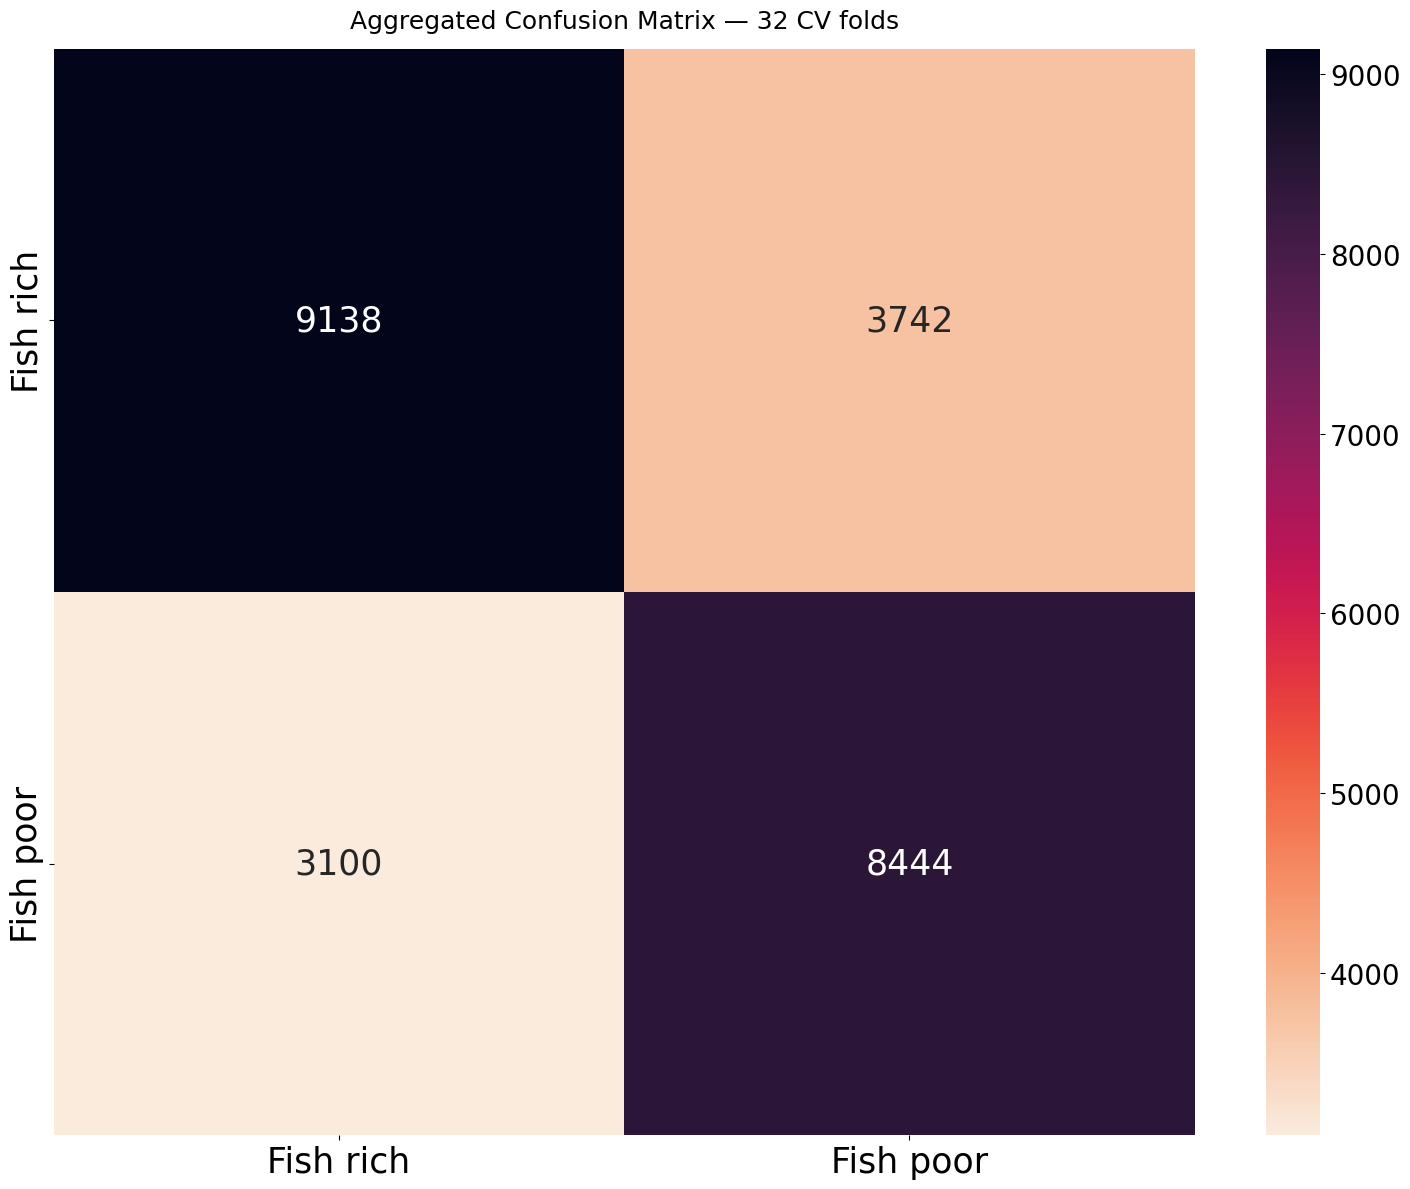

In [8]:
# ── BASELINE (unchanged from REPRODUCTION notebook) ───────────────────────────
array = ConfusionMatrix
df_cm = pd.DataFrame(array, index=["Fish rich", "Fish poor"],
                     columns=["Fish rich", "Fish poor"])
plt.figure(figsize=(15, 12))
cmap = sn.cm.rocket_r
ax = sn.heatmap(df_cm, annot=True, annot_kws={"fontsize": 25}, fmt='g', cmap=cmap)
ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize=25)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize=25)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
plt.title('Aggregated Confusion Matrix — 32 CV folds', fontsize=18, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUTPUT_DIR, 'baseline_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9 — Pool SHAP data across all 32 folds and save to disk

Saving now means the expensive analysis cells (10–15) can be re-run
without repeating the full training loop.

In [9]:
# ── [SHAP] Pool and verify ────────────────────────────────────────────────────
all_sv    = np.concatenate(shap_fold_sv,          axis=0)   # [N_total, 128]
all_feats = np.concatenate(shap_fold_test_feats,  axis=0)   # [N_total, 128]
all_files = np.concatenate(shap_fold_filenames,   axis=0)   # [N_total]
all_labs  = np.concatenate(shap_fold_labels,      axis=0)   # [N_total]
all_preds = np.concatenate(shap_fold_predictions, axis=0)   # [N_total]
all_proba = np.concatenate(shap_fold_proba,       axis=0)   # [N_total, 2]
all_base  = np.array(shap_fold_expected_val)                # [32]

all_sample_base_vals = np.concatenate([
    np.full(len(sv), base) for sv, base in zip(shap_fold_sv, shap_fold_expected_val)
])
all_sample_fold_ids = np.concatenate([
    np.full(len(sv), str(fid)) for sv, fid in zip(shap_fold_sv, shap_fold_ids)
])

print(f'all_sv shape:    {all_sv.shape}    (expected [N_total, 128])')
print(f'all_feats shape: {all_feats.shape}')
print(f'all_labs shape:  {all_labs.shape}')
print(f'all_base shape:  {all_base.shape}  (one expected value per fold)')
assert all_sv.shape[1] == 128, f'Expected 128 features, got {all_sv.shape[1]}'
print('Shape assertion passed.')

# Per-fold mean |SHAP|: shape [32, 128] — mirrors per-fold accuracy reporting
fold_mean_abs = np.stack([np.abs(sv).mean(axis=0) for sv in shap_fold_sv])  # [32, 128]
assert fold_mean_abs.shape == (32, 128), f'Unexpected shape: {fold_mean_abs.shape}'
print(f'fold_mean_abs shape: {fold_mean_abs.shape}  ✓')

# ── Save all arrays ───────────────────────────────────────────────────────────
np.save(os.path.join(SHAP_OUTPUT_DIR, 'shap_values_highfish_all_folds.npy'),  all_sv)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'test_feats_all_folds.npy'),            all_feats)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'test_labels_all_folds.npy'),           all_labs)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'test_predictions_all_folds.npy'),      all_preds)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'test_proba_all_folds.npy'),            all_proba)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'test_filenames_all_folds.npy'),        all_files)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'shap_fold_mean_abs.npy'),              fold_mean_abs)
np.save(os.path.join(SHAP_OUTPUT_DIR, 'shap_fold_expected_values.npy'),       all_base)

with open(os.path.join(SHAP_OUTPUT_DIR, 'fold_ids.json'), 'w') as fh:
    json.dump([list(fid) for fid in shap_fold_ids], fh, indent=2)

print('\nFiles saved:')
for f in sorted(os.listdir(SHAP_OUTPUT_DIR)):
    fpath = os.path.join(SHAP_OUTPUT_DIR, f)
    print(f'  {f:<55} {os.path.getsize(fpath)/1024:>8.1f} KB')

all_sv shape:    (24424, 128)    (expected [N_total, 128])
all_feats shape: (24424, 128)
all_labs shape:  (24424,)
all_base shape:  (32,)  (one expected value per fold)
Shape assertion passed.
fold_mean_abs shape: (32, 128)  ✓

Files saved:
  baseline_confusion_matrix.png                               87.9 KB
  fold_ids.json                                                2.1 KB
  shap_beeswarm_top20.png                                    350.4 KB
  shap_class_specific.png                                    114.4 KB
  shap_correct_vs_incorrect.png                              117.6 KB
  shap_fold_expected_values.npy                                0.4 KB
  shap_fold_mean_abs.npy                                      32.1 KB
  shap_global_importance.csv                                   8.0 KB
  shap_global_importance_bar.png                             105.6 KB
  shap_values_highfish_all_folds.npy                       24424.1 KB
  test_feats_all_folds.npy                                 

---
## Cell 10 — Global SHAP importance (mean ± std across 32 folds)

In [10]:
# ── [SHAP] Global importance ──────────────────────────────────────────────────
# fold_mean_abs: [32, 128] — one mean |SHAP| per dimension per fold.
# Taking mean/std across the 32 fold-means mirrors the accuracy reporting convention.

global_mean_importance = fold_mean_abs.mean(axis=0)   # [128]
global_std_importance  = fold_mean_abs.std(axis=0)    # [128]

assert global_mean_importance.shape == (128,), f'Expected (128,), got {global_mean_importance.shape}'

rank_order = np.argsort(global_mean_importance)[::-1]   # descending rank

print('Top 20 most important VGGish dimensions (cross-fold mean |SHAP|):')
print(f'{"Rank":<6} {"Dimension":<18} {"Mean |SHAP|":<14} {"± Std"}')
print('-' * 55)
for rank, dim in enumerate(rank_order[:20]):
    print(f'{rank+1:<6} VGGish_dim_{dim:<7} {global_mean_importance[dim]:.6f}      '
          f'± {global_std_importance[dim]:.6f}')

# Save as CSV for paper tables
importance_df = pd.DataFrame({
    'rank':          np.arange(1, 129),
    'dimension':     [FEATURE_NAMES[d] for d in rank_order],
    'dim_index':     rank_order,
    'mean_abs_shap': global_mean_importance[rank_order],
    'std_abs_shap':  global_std_importance[rank_order],
})
importance_df.to_csv(os.path.join(SHAP_OUTPUT_DIR, 'shap_global_importance.csv'), index=False)
print('\nGlobal importance CSV saved.')
importance_df.head(20)

Top 20 most important VGGish dimensions (cross-fold mean |SHAP|):
Rank   Dimension          Mean |SHAP|    ± Std
-------------------------------------------------------
1      VGGish_dim_54      0.038127      ± 0.012707
2      VGGish_dim_94      0.032894      ± 0.006689
3      VGGish_dim_16      0.030671      ± 0.012273
4      VGGish_dim_60      0.024473      ± 0.006983
5      VGGish_dim_95      0.020466      ± 0.005192
6      VGGish_dim_102     0.019647      ± 0.005692
7      VGGish_dim_111     0.019262      ± 0.005600
8      VGGish_dim_84      0.016667      ± 0.005405
9      VGGish_dim_89      0.015583      ± 0.004727
10     VGGish_dim_91      0.015146      ± 0.006700
11     VGGish_dim_64      0.014726      ± 0.006377
12     VGGish_dim_119     0.013068      ± 0.004947
13     VGGish_dim_7       0.011098      ± 0.005635
14     VGGish_dim_101     0.010260      ± 0.004372
15     VGGish_dim_27      0.010227      ± 0.004154
16     VGGish_dim_20      0.009678      ± 0.002607
17     VGGish_d

,rank,dimension,dim_index,mean_abs_shap,std_abs_shap
0,1,VGGish_dim_54,54,0.038127,0.012707
1,2,VGGish_dim_94,94,0.032894,0.006689
2,3,VGGish_dim_16,16,0.030671,0.012273
3,4,VGGish_dim_60,60,0.024473,0.006983
4,5,VGGish_dim_95,95,0.020466,0.005192
5,6,VGGish_dim_102,102,0.019647,0.005692
6,7,VGGish_dim_111,111,0.019262,0.005600
7,8,VGGish_dim_84,84,0.016667,0.005405
8,9,VGGish_dim_89,89,0.015583,0.004727
9,10,VGGish_dim_91,91,0.015146,0.006700


---
## Cross-Fold Stability Analysis

Evaluate how consistently the top VGGish dimensions rank across all 32 folds.

In [11]:
# ── [SHAP] Cross-Fold Stability ─────────────────────────────────────────────
print('=== Cross-Fold Stability Analysis (Top 20 Dimensions) ===\n')

fold_ranks = np.zeros_like(fold_mean_abs, dtype=int)
for i in range(fold_mean_abs.shape[0]):
    # argsort(argsort(-x)) gives 0 to the highest value
    ranks = np.argsort(np.argsort(-fold_mean_abs[i]))
    fold_ranks[i] = ranks

top20_dims = rank_order[:20]

stability_data = []
for dim in top20_dims:
    mean_val = global_mean_importance[dim]
    std_val = global_std_importance[dim]
    top10_count = np.sum(fold_ranks[:, dim] < 10)
    top20_count = np.sum(fold_ranks[:, dim] < 20)
    
    stability_data.append({
        'Dimension': FEATURE_NAMES[dim],
        'Global Mean |SHAP|': mean_val,
        'Cross-fold Std': std_val,
        'Folds in Top 10': top10_count,
        'Folds in Top 20': top20_count
    })

stability_df = pd.DataFrame(stability_data)
print(stability_df.to_string(index=False))
stability_df.to_csv(os.path.join(SHAP_OUTPUT_DIR, 'shap_cross_fold_stability.csv'), index=False)


=== Cross-Fold Stability Analysis (Top 20 Dimensions) ===

     Dimension  Global Mean |SHAP|  Cross-fold Std  Folds in Top 10  Folds in Top 20
 VGGish_dim_54            0.038127        0.012707               32               32
 VGGish_dim_94            0.032894        0.006689               32               32
 VGGish_dim_16            0.030671        0.012273               31               32
 VGGish_dim_60            0.024473        0.006983               28               32
 VGGish_dim_95            0.020466        0.005192               27               32
VGGish_dim_102            0.019647        0.005692               28               32
VGGish_dim_111            0.019262        0.005600               23               31
 VGGish_dim_84            0.016667        0.005405               17               29
 VGGish_dim_89            0.015583        0.004727               17               32
 VGGish_dim_91            0.015146        0.006700               19               25
 VGGis

---
## Cell 11 — SHAP beeswarm summary plot (pooled across 32 folds)

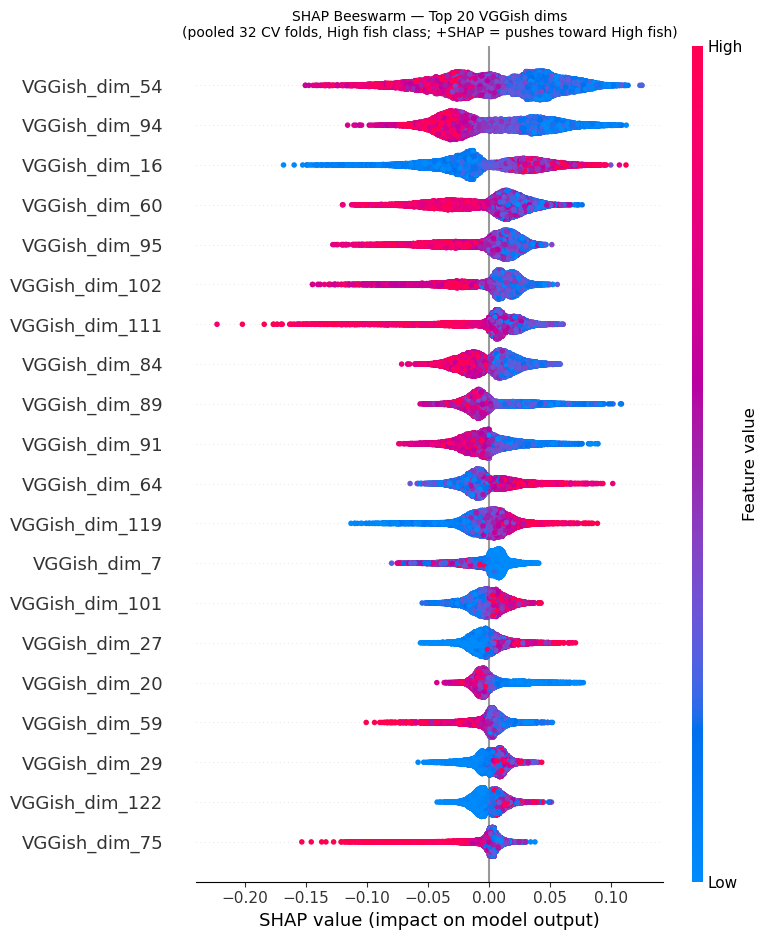

Beeswarm plot saved.


In [12]:
# ── [SHAP] Beeswarm summary plot ──────────────────────────────────────────────
# all_sv:    SHAP values for 'High fish' class [N_total, 128]
# all_feats: corresponding VGGish feature values [N_total, 128]
# Positive SHAP → pushes prediction toward 'High fish'
# Negative SHAP → pushes prediction toward 'Low fish'

plt.figure()
shap.summary_plot(
    all_sv,
    all_feats,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Beeswarm — Top 20 VGGish dims\n'
          '(pooled 32 CV folds, High fish class; +SHAP = pushes toward High fish)',
          fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUTPUT_DIR, 'shap_beeswarm_top20.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Beeswarm plot saved.')

---
## Cell 12 — Global mean-absolute SHAP bar chart (± cross-fold std)

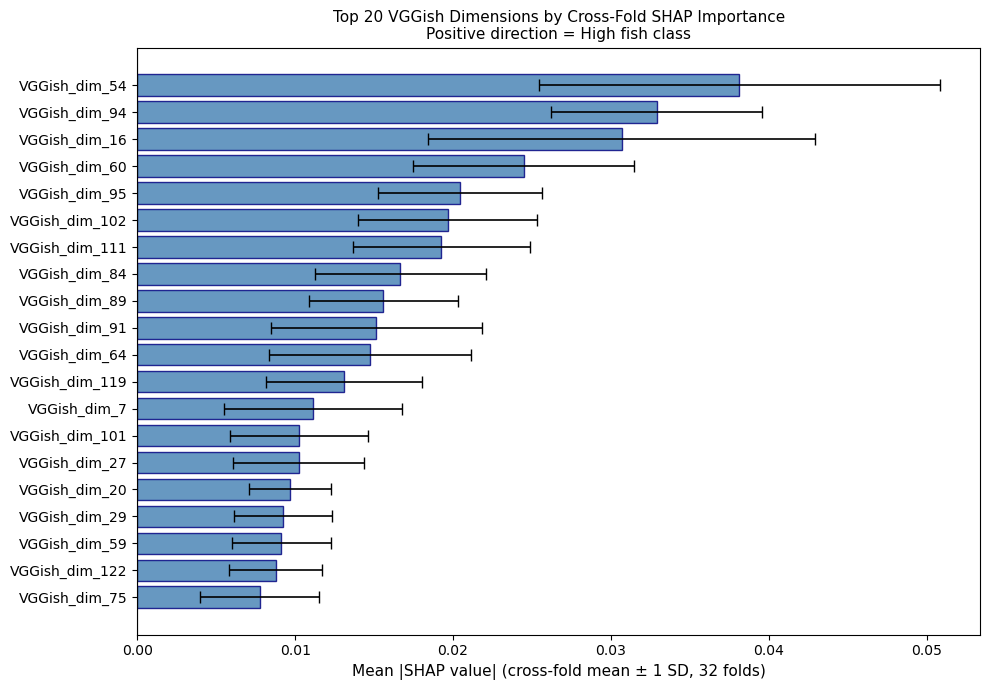

Global importance bar chart saved.


In [13]:
# ── [SHAP] Global importance bar chart ───────────────────────────────────────
top_n = 20
top_dims  = rank_order[:top_n]
top_names = [FEATURE_NAMES[d] for d in top_dims]
top_means = global_mean_importance[top_dims]
top_stds  = global_std_importance[top_dims]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    range(top_n), top_means[::-1],
    xerr=top_stds[::-1],
    color='steelblue', alpha=0.82, edgecolor='navy',
    error_kw=dict(ecolor='black', lw=1.2, capsize=4)
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP value| (cross-fold mean ± 1 SD, 32 folds)', fontsize=11)
ax.set_title(f'Top {top_n} VGGish Dimensions by Cross-Fold SHAP Importance\n'
             f'Positive direction = High fish class', fontsize=11)
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUTPUT_DIR, 'shap_global_importance_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Global importance bar chart saved.')

---
## Cell 13 — Class-specific SHAP analysis

Separate SHAP distributions for 'High fish' and 'Low fish' samples reveal
which VGGish dimensions most strongly drive each class's predictions.

High fish test samples: 12880
Low fish test samples:  11544


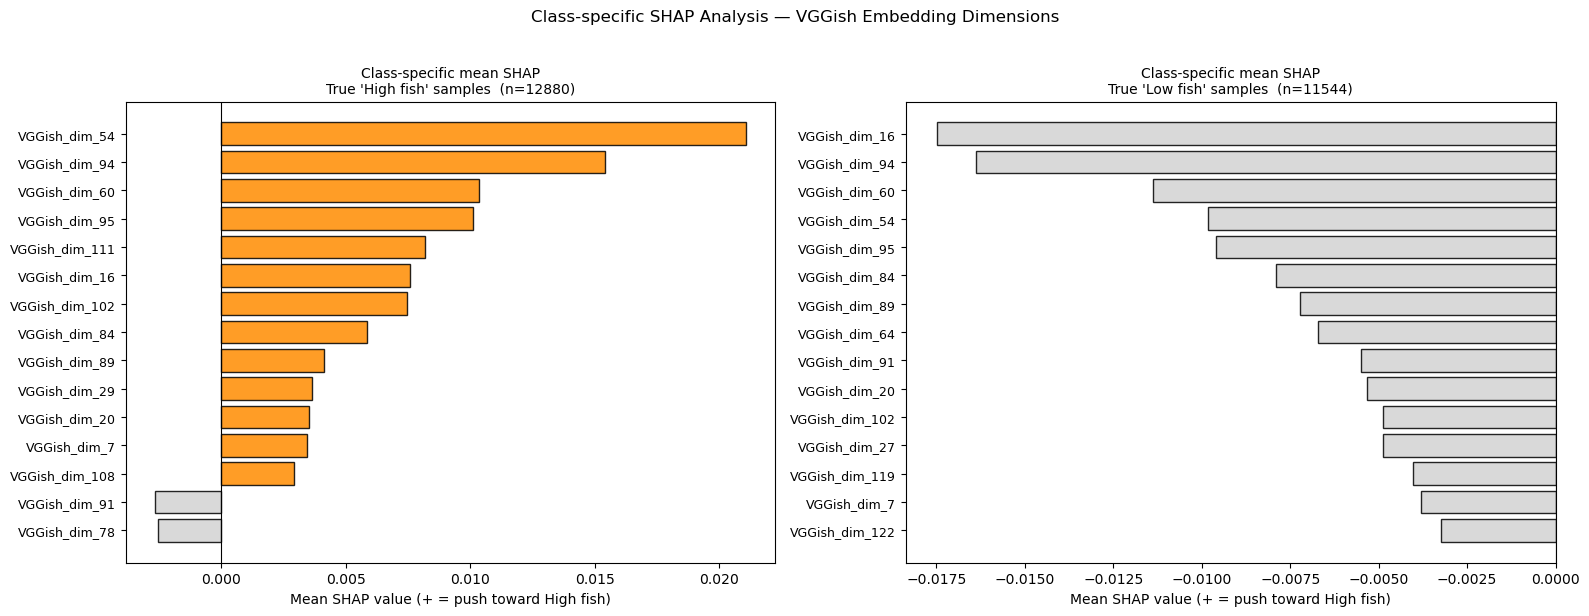

In [14]:
# ── [SHAP] Class-specific mean SHAP ───────────────────────────────────────────
hf_mask = (all_labs == 'High fish')
lf_mask = (all_labs == 'Low fish')
print(f'High fish test samples: {hf_mask.sum()}')
print(f'Low fish test samples:  {lf_mask.sum()}')

# Signed mean SHAP per class (which dims consistently push toward / away from High fish)
mean_sv_hf = all_sv[hf_mask].mean(axis=0)   # [128] — for High fish ground-truth samples
mean_sv_lf = all_sv[lf_mask].mean(axis=0)   # [128] — for Low fish ground-truth samples

top_n_class = 15
hf_rank = np.argsort(np.abs(mean_sv_hf))[::-1][:top_n_class]
lf_rank = np.argsort(np.abs(mean_sv_lf))[::-1][:top_n_class]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, title, sv_vals, rank_idx, n_samp, colour in [
    (axes[0], "True 'High fish' samples", mean_sv_hf, hf_rank, hf_mask.sum(), 'darkorange'),
    (axes[1], "True 'Low fish' samples",  mean_sv_lf, lf_rank, lf_mask.sum(), 'steelblue'),
]:
    names  = [FEATURE_NAMES[d] for d in rank_idx[::-1]]
    values = sv_vals[rank_idx[::-1]]
    colours_bar = [colour if v > 0 else 'lightgrey' for v in values]
    ax.barh(range(top_n_class), values, color=colours_bar, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_n_class))
    ax.set_yticklabels(names, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean SHAP value (+ = push toward High fish)', fontsize=10)
    ax.set_title(f'Class-specific mean SHAP\n{title}  (n={n_samp})', fontsize=10)

plt.suptitle('Class-specific SHAP Analysis — VGGish Embedding Dimensions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUTPUT_DIR, 'shap_class_specific.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 14 — Correct vs. incorrect SHAP profiles

Correct:   17582 (72.0%)
Incorrect: 6842 (28.0%)


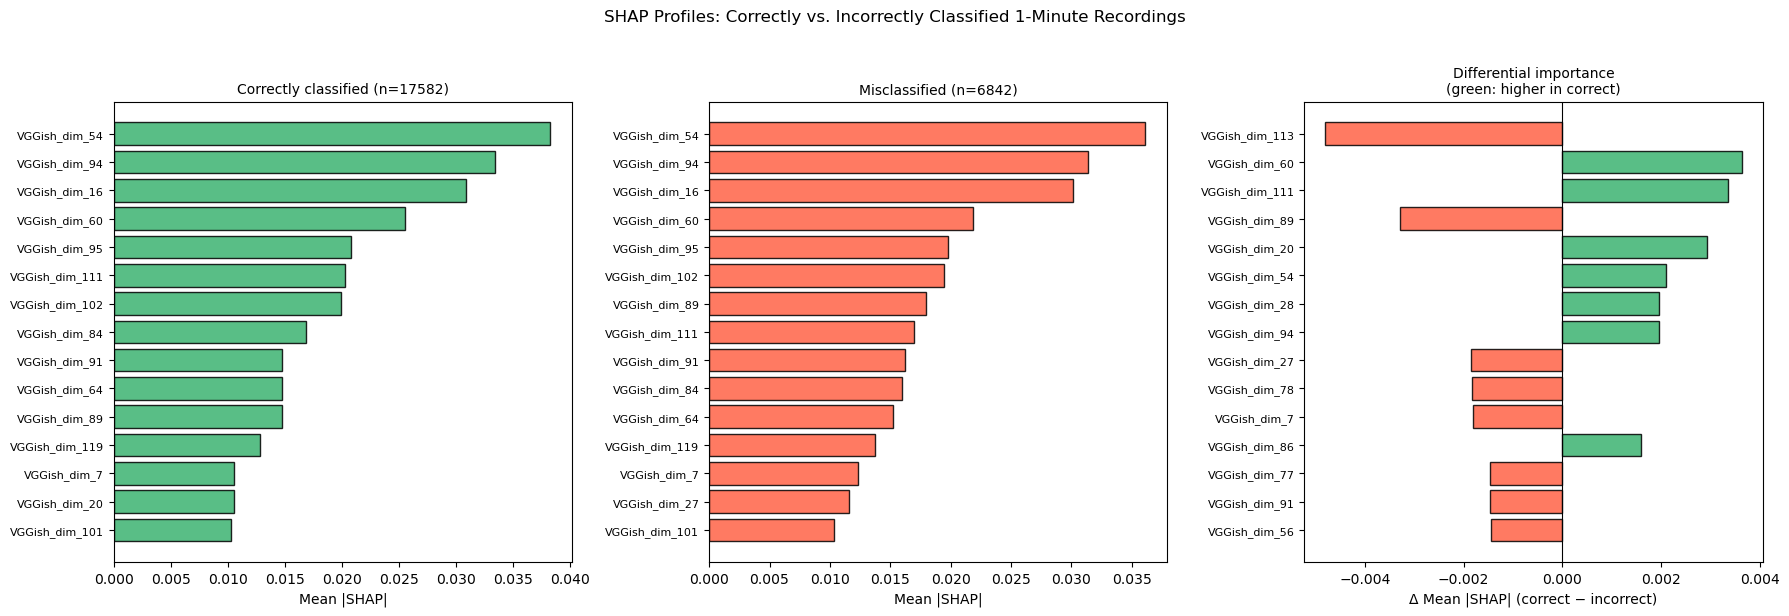

In [15]:
# ── [SHAP] Correct vs incorrect SHAP ─────────────────────────────────────────
correct_mask   = (all_preds == all_labs)
incorrect_mask = ~correct_mask

print(f'Correct:   {correct_mask.sum()} ({100*correct_mask.mean():.1f}%)')
print(f'Incorrect: {incorrect_mask.sum()} ({100*incorrect_mask.mean():.1f}%)')

mean_sv_correct   = np.abs(all_sv[correct_mask]).mean(axis=0)    # [128]
mean_sv_incorrect = np.abs(all_sv[incorrect_mask]).mean(axis=0)  # [128]
diff_importance   = mean_sv_correct - mean_sv_incorrect           # [128]

top_c    = np.argsort(mean_sv_correct)[::-1][:15]
top_w    = np.argsort(mean_sv_incorrect)[::-1][:15]
diff_rank = np.argsort(np.abs(diff_importance))[::-1][:15]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: correct
axes[0].barh(range(15), mean_sv_correct[top_c[::-1]], color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([FEATURE_NAMES[d] for d in top_c[::-1]], fontsize=8)
axes[0].set_xlabel('Mean |SHAP|', fontsize=10)
axes[0].set_title(f'Correctly classified (n={correct_mask.sum()})', fontsize=10)

# Middle: incorrect
axes[1].barh(range(15), mean_sv_incorrect[top_w[::-1]], color='tomato', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([FEATURE_NAMES[d] for d in top_w[::-1]], fontsize=8)
axes[1].set_xlabel('Mean |SHAP|', fontsize=10)
axes[1].set_title(f'Misclassified (n={incorrect_mask.sum()})', fontsize=10)

# Right: differential
diff_vals   = diff_importance[diff_rank[::-1]]
diff_colors = ['mediumseagreen' if v > 0 else 'tomato' for v in diff_vals]
axes[2].barh(range(15), diff_vals, color=diff_colors, edgecolor='black', alpha=0.85)
axes[2].set_yticks(range(15))
axes[2].set_yticklabels([FEATURE_NAMES[d] for d in diff_rank[::-1]], fontsize=8)
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_xlabel('Δ Mean |SHAP| (correct − incorrect)', fontsize=10)
axes[2].set_title('Differential importance\n(green: higher in correct)', fontsize=10)

plt.suptitle('SHAP Profiles: Correctly vs. Incorrectly Classified 1-Minute Recordings', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SHAP_OUTPUT_DIR, 'shap_correct_vs_incorrect.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 15 — Representative waterfall plots

Waterfall plots for the most confidently correct and most confidently incorrect
held-out examples in each class, with recording filename for full traceability.

=== Representative waterfall plots ===



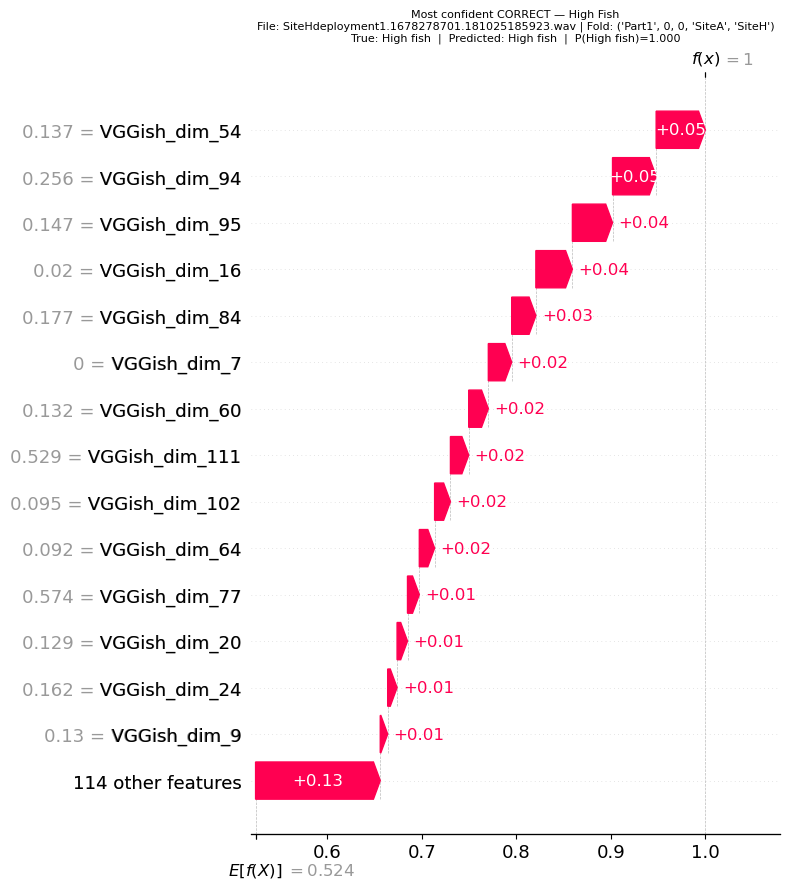

  [waterfall_correct_highfish.png]
    Recording : SiteHdeployment1.1678278701.181025185923.wav
    Fold      : ('Part1', 0, 0, 'SiteA', 'SiteH')
    Base Val  : 0.5241
    True      : High fish
    Predicted : High fish
    P(HF)     : 1.0000



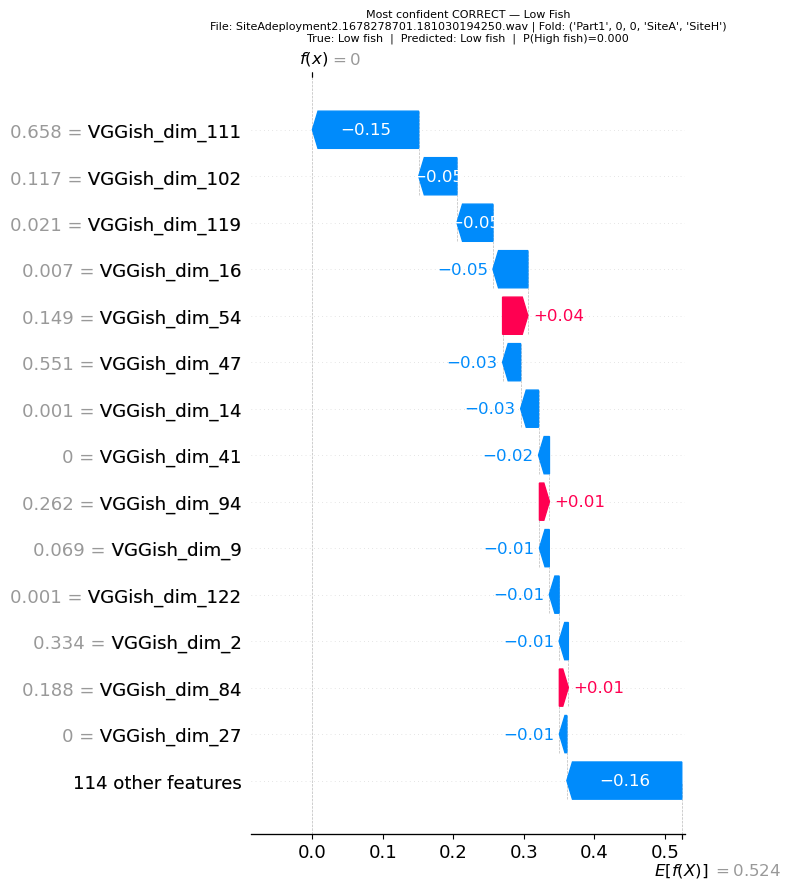

  [waterfall_correct_lowfish.png]
    Recording : SiteAdeployment2.1678278701.181030194250.wav
    Fold      : ('Part1', 0, 0, 'SiteA', 'SiteH')
    Base Val  : 0.5241
    True      : Low fish
    Predicted : Low fish
    P(HF)     : 0.0000



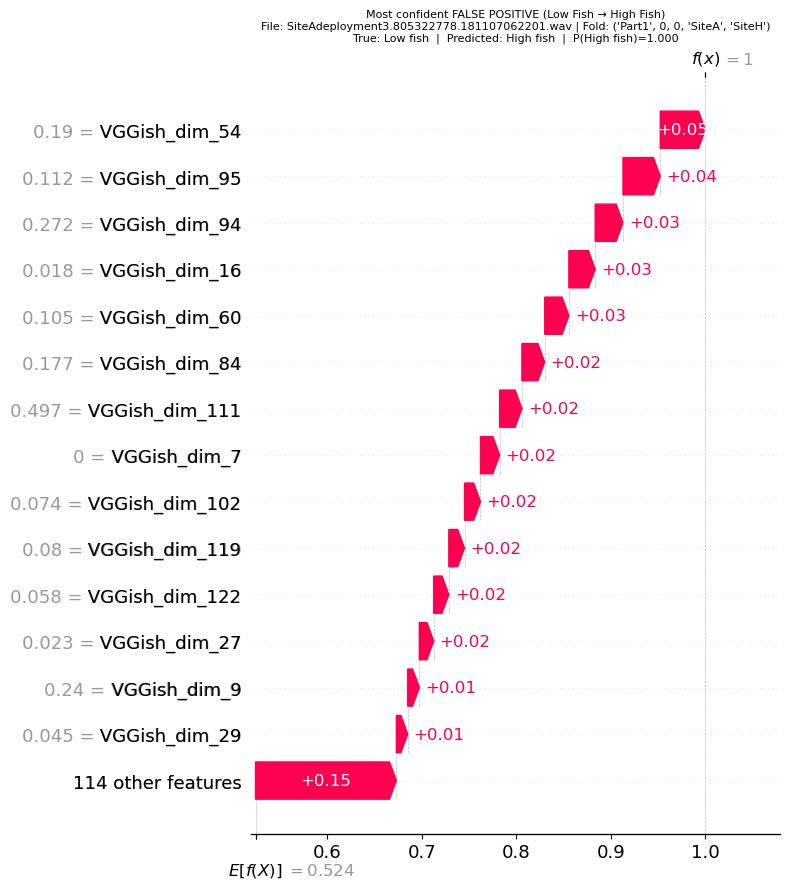

  [waterfall_false_positive.png]
    Recording : SiteAdeployment3.805322778.181107062201.wav
    Fold      : ('Part1', 0, 0, 'SiteA', 'SiteH')
    Base Val  : 0.5241
    True      : Low fish
    Predicted : High fish
    P(HF)     : 1.0000



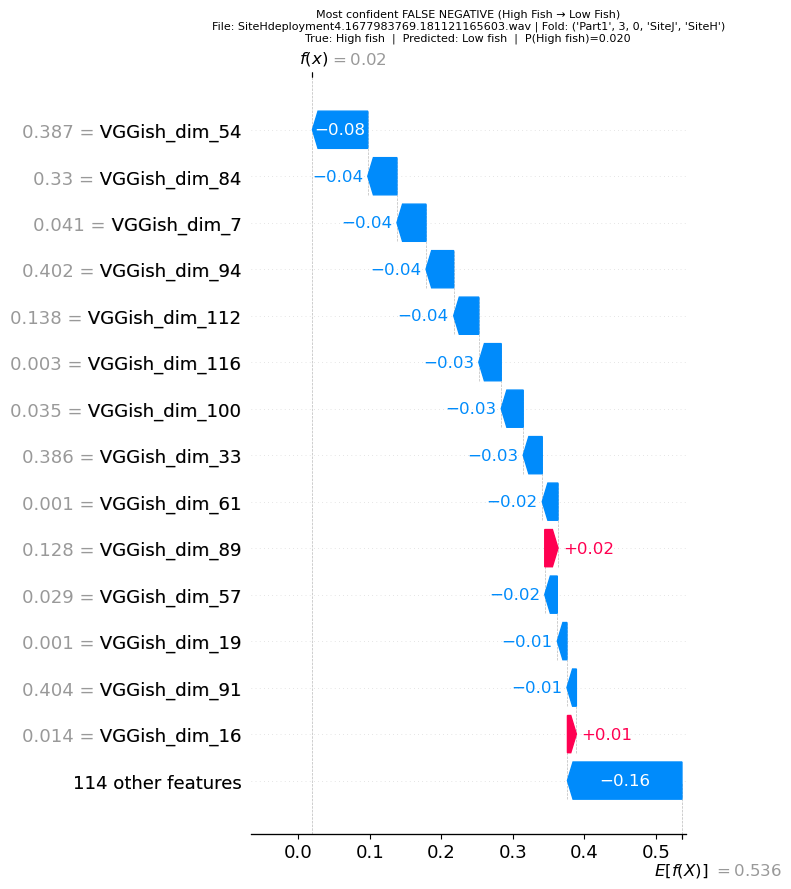

  [waterfall_false_negative.png]
    Recording : SiteHdeployment4.1677983769.181121165603.wav
    Fold      : ('Part1', 3, 0, 'SiteJ', 'SiteH')
    Base Val  : 0.5361
    True      : High fish
    Predicted : Low fish
    P(HF)     : 0.0200

All waterfall plots saved.


In [16]:
# ── [SHAP] Waterfall plots ────────────────────────────────────────────────────
# Use class probability as the confidence metric.
# all_proba[:, hf_proba_idx] = P(High fish), where model.classes_[0] = 'High fish'
hf_proba_idx = shap_fold_classes_[0].index('High fish')   # 0
p_highfish   = all_proba[:, hf_proba_idx]                  # [N_total]

def save_waterfall(sample_idx, title_str, filename):
    """Build and save a SHAP waterfall plot for a single test sample."""
    sample_base_val = all_sample_base_vals[sample_idx]
    sample_fold_id = all_sample_fold_ids[sample_idx]
    single_exp = shap.Explanation(
        values=all_sv[sample_idx],
        base_values=sample_base_val,
        data=all_feats[sample_idx],
        feature_names=FEATURE_NAMES
    )
    plt.figure()
    shap.plots.waterfall(single_exp, max_display=15, show=False)
    true_lbl = all_labs[sample_idx]
    pred_lbl = all_preds[sample_idx]
    conf     = p_highfish[sample_idx]
    plt.title(
        f'{title_str}\n'
        f'File: {all_files[sample_idx]} | Fold: {sample_fold_id}\n'
        f'True: {true_lbl}  |  Predicted: {pred_lbl}  |  P(High fish)={conf:.3f}',
        fontsize=8
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SHAP_OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  [{filename}]')
    print(f'    Recording : {all_files[sample_idx]}')
    print(f'    Fold      : {sample_fold_id}')
    print(f'    Base Val  : {sample_base_val:.4f}')
    print(f'    True      : {true_lbl}')
    print(f'    Predicted : {pred_lbl}')
    print(f'    P(HF)     : {conf:.4f}')
    print()

print('=== Representative waterfall plots ===\n')

# (a) Most confident CORRECT High Fish prediction
hf_correct_mask = correct_mask & hf_mask
if hf_correct_mask.sum() > 0:
    idx = np.where(hf_correct_mask)[0][np.argmax(p_highfish[hf_correct_mask])]
    save_waterfall(idx, 'Most confident CORRECT — High Fish', 'waterfall_correct_highfish.png')

# (b) Most confident CORRECT Low Fish prediction
lf_correct_mask = correct_mask & lf_mask
if lf_correct_mask.sum() > 0:
    idx = np.where(lf_correct_mask)[0][np.argmin(p_highfish[lf_correct_mask])]
    save_waterfall(idx, 'Most confident CORRECT — Low Fish', 'waterfall_correct_lowfish.png')

# (c) Most confident FALSE POSITIVE (true Low Fish predicted as High Fish)
fp_mask = incorrect_mask & lf_mask
if fp_mask.sum() > 0:
    idx = np.where(fp_mask)[0][np.argmax(p_highfish[fp_mask])]
    save_waterfall(idx, 'Most confident FALSE POSITIVE (Low Fish → High Fish)', 'waterfall_false_positive.png')

# (d) Most confident FALSE NEGATIVE (true High Fish predicted as Low Fish)
fn_mask = incorrect_mask & hf_mask
if fn_mask.sum() > 0:
    idx = np.where(fn_mask)[0][np.argmin(p_highfish[fn_mask])]
    save_waterfall(idx, 'Most confident FALSE NEGATIVE (High Fish → Low Fish)', 'waterfall_false_negative.png')

print('All waterfall plots saved.')


---
## Cell 16 — Final summary

In [17]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 70)
print('SHAP ANALYSIS COMPLETE')
print('=' * 70)
print()
print('Baseline metrics (unchanged, 32-fold CV):')
print(f'  Per-minute accuracy: {Average(both_saved_test_accs):.4f} ± {np.std(both_saved_test_accs):.4f}')
print(f'  Site-level accuracy: {Average(both_whole_site_saved_test_accs):.4f} ± {np.std(both_whole_site_saved_test_accs):.4f}')
print()
print(f'SHAP summary:')
print(f'  Folds collected:  {len(shap_fold_sv)}')
print(f'  Total test recs:  {len(all_labs)}')
print(f'  Correctly classified: {correct_mask.sum()} ({100*correct_mask.mean():.1f}%)')
print(f'  Misclassified:        {incorrect_mask.sum()} ({100*incorrect_mask.mean():.1f}%)')
print()
print('Top 5 VGGish dimensions by cross-fold mean |SHAP|:')
for rank in range(5):
    d = rank_order[rank]
    print(f'  {rank+1}. VGGish_dim_{d:<3}  mean|SHAP|={global_mean_importance[d]:.5f} ± {global_std_importance[d]:.5f}')
print()
print('Outputs saved to:', SHAP_OUTPUT_DIR)
for f in sorted(os.listdir(SHAP_OUTPUT_DIR)):
    fpath = os.path.join(SHAP_OUTPUT_DIR, f)
    print(f'  {f:<55} {os.path.getsize(fpath)/1024:>8.1f} KB')
print()
print('INTERPRETATION REMINDER:')
print('  VGGish dims 0-127 are LEARNED EMBEDDINGS — not physical frequency bands.')
print('  Valid claim: "The RF relies most on VGGish dims X, Y, Z."')
print('  Invalid claim: "Dim X corresponds to snapping shrimp at Y Hz."')

SHAP ANALYSIS COMPLETE

Baseline metrics (unchanged, 32-fold CV):
  Per-minute accuracy: 0.7194 ± 0.0855
  Site-level accuracy: 1.0000 ± 0.0000

SHAP summary:
  Folds collected:  32
  Total test recs:  24424
  Correctly classified: 17582 (72.0%)
  Misclassified:        6842 (28.0%)

Top 5 VGGish dimensions by cross-fold mean |SHAP|:
  1. VGGish_dim_54   mean|SHAP|=0.03813 ± 0.01271
  2. VGGish_dim_94   mean|SHAP|=0.03289 ± 0.00669
  3. VGGish_dim_16   mean|SHAP|=0.03067 ± 0.01227
  4. VGGish_dim_60   mean|SHAP|=0.02447 ± 0.00698
  5. VGGish_dim_95   mean|SHAP|=0.02047 ± 0.00519

Outputs saved to: C:\Code\Reef-acoustics-and-AI-main\outputs\shap_aus_habitat
  baseline_confusion_matrix.png                               87.9 KB
  fold_ids.json                                                2.1 KB
  shap_beeswarm_top20.png                                    349.9 KB
  shap_class_specific.png                                    114.4 KB
  shap_correct_vs_incorrect.png                         